In [30]:
import zipfile

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Files extracted successfully!")

Files extracted successfully!


In [6]:
import os

print(os.listdir())

['.config', 'Genre Classification Dataset', 'archive (1).zip', 'sample_data']


In [7]:
import os

print(os.listdir("Genre Classification Dataset"))

['test_data_solution.txt', 'description.txt', 'test_data.txt', 'train_data.txt']


In [8]:
with open("Genre Classification Dataset/train_data.txt", "r", encoding="utf-8") as file:
    lines = file.readlines()

print(lines[:5])

['1 ::: Oscar et la dame rose (2009) ::: drama ::: Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.\n', '2 ::: Cupid (1997) ::: thriller ::: A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close to him.\n', '3 ::: Young, Wild and Wonderful (1980) ::: adult ::: As the bus empties the students for their field trip to the Museum of Natural History, little does the tour guide suspec

In [9]:
import pandas as pd

In [12]:
data=[]
with open ('Genre Classification Dataset/train_data.txt','r',encoding='utf-8')as file:
  for line in file:
    parts=line.split(':::')
    if len(parts)==4:
      data.append(parts)
movie_data=pd.DataFrame(data,columns=['ID','TITLE','GENRE','DESCRIPTION'])
movie_data.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [13]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  object
 1   TITLE        54214 non-null  object
 2   GENRE        54214 non-null  object
 3   DESCRIPTION  54214 non-null  object
dtypes: object(4)
memory usage: 1.7+ MB


In [14]:
movie_data.dropna(inplace=True)

In [15]:
import matplotlib.pyplot as plt

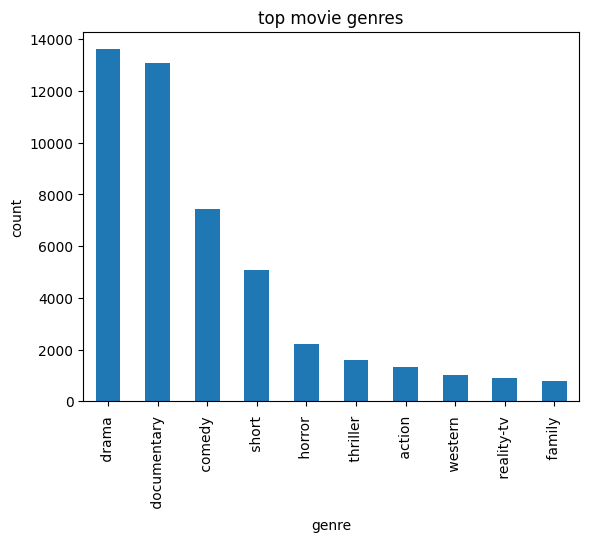

In [16]:
movie_data['GENRE'].value_counts().head(10).plot(kind='bar')
plt.xlabel('genre')
plt.ylabel('count')
plt.title("top movie genres")
plt.show()

In [17]:
x=movie_data['DESCRIPTION']
y=movie_data['GENRE']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
tfidf_vectorizer=TfidfVectorizer(stop_words='english')

In [25]:
x_train=tfidf_vectorizer.fit_transform(x_train)
x_test=tfidf_vectorizer.transform(x_test)

In [26]:
from sklearn.linear_model import LogisticRegression

In [31]:
genre_classifier=LogisticRegression(max_iter=1000)
genre_classifier.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [32]:
prediction=genre_classifier.predict(x_test)

In [33]:
from sklearn.metrics import accuracy_score

In [35]:
accuracy=accuracy_score(y_test,prediction)
print('accuracy:',accuracy)

accuracy: 0.5801899843216822


In [38]:
sample_plot=['A family moves into a haunted house where terrifying spirits appear every night']
sample_vector=tfidf_vectorizer.transform(sample_plot)
predicted_genre=genre_classifier.predict(sample_vector)
print('predicted genre is:',predicted_genre[0])

predicted genre is:  horror 
